In [123]:
%matplotlib inline

from pathlib import Path
import importlib.util
import urllib.request
import zipfile
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd
from scipy import sparse
from scipy.io import loadmat
from scipy.sparse.csgraph import connected_components

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
!pip install dgl
!pip install torchdata==0.9.0

In [6]:
from dgl.data import FraudYelpDataset

# EDA - Yelp Dataset

In [19]:
dataset = FraudYelpDataset()

graph = dataset[0]
X = graph.ndata["feature"].float()
y = g.ndata["label"].long()

train_mask = graph.ndata["train_mask"].bool()
val_mask = graph.ndata["val_mask"].bool()
test_mask = graph.ndata["test_mask"].bool()

Done loading data from cached files.


In [20]:
N = g.num_nodes()

print(g)
print("Number of nodes:", N)
print("Feature shape:", X.shape)
print("Label counts:", torch.bincount(y))
print(f"Train / Val / Test: {train_mask.sum().item()}/{val_mask.sum().item()}/{test_mask.sum().item()}")
print("Relations:", g.etypes)

Graph(num_nodes={'review': 45954},
      num_edges={('review', 'net_rsr', 'review'): 6805486, ('review', 'net_rtr', 'review'): 1147232, ('review', 'net_rur', 'review'): 98630},
      metagraph=[('review', 'review', 'net_rsr'), ('review', 'review', 'net_rtr'), ('review', 'review', 'net_rur')])
Number of nodes: 45954
Feature shape: torch.Size([45954, 32])
Label counts: tensor([39277,  6677])
Train / Val / Test: 32167/4595/9192
Relations: ['net_rsr', 'net_rtr', 'net_rur']


In [77]:
def to_numpy(t):
    if isinstance(t, torch.Tensor):
        return t.detach().cpu().numpy()
    return np.asarray(t)

def get_edges_np(g, etype):
    src, dst = g.edges(etype=etype)
    src = to_numpy(src).astype(np.int64)
    dst = to_numpy(dst).astype(np.int64)
    keep = src != dst
    return src[keep], dst[keep]

X = to_numpy(X)
Y = to_numpy(y)

train_idx = to_numpy(train_mask)
val_idx = to_numpy(val_mask)
test_idx = to_numpy(test_mask)

N = g.num_nodes()
relations = list(g.etypes)

# Precompute edge arrays for speed.
edge_arrays = {}
for r in relations:
    edge_arrays[r] = get_edges_np(g, r)

print("Fraud rate overall:", Y.mean())
print("Fraud rate train:", Y[train_idx].mean())
print("Fraud rate val:", Y[val_idx].mean())
print("Fraud rate test:", Y[test_idx].mean())

Fraud rate overall: 0.14529747138442792
Fraud rate train: 0.14692075729785184
Fraud rate val: 0.14167573449401524
Fraud rate test: 0.1414273281114012


In [10]:
label_counts = pd.Series(Y).value_counts().sort_index()
label_summary = pd.DataFrame({
    "label": ["legitimate_0", "fraud_1"],
    "count": [label_counts.get(0, 0), label_counts.get(1, 0)],
})
label_summary["fraction"] = label_summary["count"] / label_summary["count"].sum()
label_summary

,label,count,fraction
0,legitimate_0,39277,0.854703
1,fraud_1,6677,0.145297


In [23]:
feature_df = pd.DataFrame(X, columns=[f"feat_{i}" for i in range(X.shape[1])])
feature_df["label"] = Y

## Evaluation Utils

In [26]:
def to_numpy(t):
    if isinstance(t, torch.Tensor):
        return t.detach().cpu().numpy()
    return np.asarray(t)


def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))


def logit_np(p, eps=1e-6):
    p = np.clip(p, eps, 1.0 - eps)
    return np.log(p / (1.0 - p))

In [28]:
def best_f1_threshold(y_true, scores):
    # after getting the scores from model, tune a best threshold for max F1 score
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    candidates = np.unique(np.concatenate([
        np.linspace(0.01, 0.99, 99),
        np.quantile(scores, np.linspace(0, 1, 101)),
    ]))
    best_threshold, best_score = 0.5, -np.inf
    for threshold in candidates:
        pred = (scores >= threshold).astype(int)
        score = f1_score(y_true, pred, zero_division=0)
        if score > best_score:
            best_threshold, best_score = float(threshold), score
    return best_threshold


def evaluate_scores(model_name, y_true, scores):
    # evaluate the model scores with threshold tuned
    threshold = best_f1_threshold(y_true[val_mask], scores[val_mask])
    y_test = y_true[test_mask]
    s_test = scores[test_mask]
    pred = (s_test >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_test, s_test),
        "average_precision": average_precision_score(y_test, s_test),
        "f1": f1_score(y_test, pred, zero_division=0),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "accuracy": accuracy_score(y_test, pred),
    }


def classifier_scores(model, x, y_true):
    model.fit(x[train_mask], y_true[train_mask])
    return model.predict_proba(x)[:, 1]


def row_normalize(adj):
    adj = sparse.csr_matrix(adj, dtype=np.float32)
    row_sum = np.asarray(adj.sum(axis=1)).reshape(-1)
    inv = np.divide(1.0, row_sum, out=np.zeros_like(row_sum, dtype=np.float32), where=row_sum > 0)
    return sparse.diags(inv) @ adj


def neighbor_vote_scores(adj, y, train_mask, smoothing=1.0):
    prior = float(y[train_mask].mean())
    known = train_mask.astype(float)
    positive = ((y == 1) & train_mask).astype(float)
    known_nbrs = adj @ known
    positive_nbrs = adj @ positive
    return (positive_nbrs + smoothing * prior) / (known_nbrs + smoothing)


def label_propagation_scores(adj, y, train_mask, alpha=0.85, n_iter=30):
    prior = float(y[train_mask].mean())
    transition = row_normalize(adj)
    scores = np.full(y.size, prior, dtype=np.float32)
    scores[train_mask] = y[train_mask].astype(np.float32)
    for _ in range(n_iter):
        scores = alpha * (transition @ scores) + (1 - alpha) * prior
        scores[train_mask] = y[train_mask].astype(np.float32)
    return np.clip(scores, 0, 1)

def make_undirected_binary(adj):
    # make undirected adjacency matrix, with edge weight constant 1
    adj = sparse.csr_matrix(adj)
    out = adj.maximum(adj.T).astype(np.int8)
    out.setdiag(0)
    out.eliminate_zeros()
    out.data[:] = 1
    return out.tocsr()

def graph_stat_features(adj, relation_adjs, y, train_mask):
    # extract graph features
    prior = float(y[train_mask].mean())
    known = train_mask.astype(float)
    positive = ((y == 1) & train_mask).astype(float)
    deg = np.asarray(adj.sum(axis=1)).reshape(-1)
    known_nbrs = adj @ known
    positive_nbrs = adj @ positive
    pieces = [
        np.log1p(deg), # log (1+degree)
        np.log1p(known_nbrs), # log (1+known neighbors)
        positive_nbrs, # fraud neighbors
        (positive_nbrs + prior) / (known_nbrs + 1.0), # percentage of fraud neighbor
        (positive_nbrs > 0).astype(float), # has fraud neighbor
    ]

    for rel_adj in relation_adjs.values():
        rel = make_undirected_binary(rel_adj)
        rel_deg = np.asarray(rel.sum(axis=1)).reshape(-1)
        rel_known = rel @ known
        rel_pos = rel @ positive
        pieces.extend([
            np.log1p(rel_deg), # log(1+type-i-degree)
            (rel_pos + prior) / (rel_known + 1.0), # percentage of fraud neighbor in terms of type-i edge,
        ])
    return np.column_stack(pieces).astype(np.float32)

## Baseline model - Logistic Regression with features only

# Graph-Laplacian Logistic Regression

Through EDA and baseline model fitting, we discovered that R-U-R edges is very homophilous. This suggests that we can treat connected components in the subgraph with only R-U-R edges as high-confidence fraud groups. Note that as R-U-R indicates edges that connect reviews under the same users, the RUR subgraph is simply a sparse graph where each connected component is a clique representing a user.

Thus, in addition to our baseline logistic regression model (where we fit with either only 32 features or with additional graph structure features), we want to add an additional lift to the fraudulent predicted probability based on the user-component, i.e. if a review is under an user which high fraudulent flag, then its probability to be a fraud review should increase. To achieve this, we introduce to the logistic regression a "lifting" term, defined as follows

$$\text{logit} \mathbb P(y_i = 1) = \ell_i + b + \gamma z_i^{\text{rur}} + u_i, $$

where $\ell_i$ is the original logit obtained through fitting a normal logistic regression, $b$ is an adjusted intercept, $u_i$ is a smoothing factor, and $z_i^{\text{rur}}$ is the "lift" logit term, defined as

$$\log \frac{\theta_i}{1 - \theta_i} - \log \frac{\hat \pi}{1 - \hat \pi},$$

where $\theta_i = \mathbb P(y_i = 1 | i \in C)$, $\hat \pi = \mathbb P(y_i = 1)$ is the train fraud rate and $C$ is the connected component that $i$ belongs to. The mathematical explanation for this lifting term is that $z_i^{\text{rur}}$ is the log of the odd ratio when we know the information of the connected component of $i$ versus default to global fraud rate.

We derive the estimate for $\hat \theta_i$ through Empirical Bayes procedure. Given a component $C$, define $n_C, f_C$ respectively the number of nodes and fraud nodes in the component $C$. The estimation for $\theta_i$ is then $\frac {k_C} {n_C}$. However, this is numerically unstable especially when $n_C$ is small, so we adapt the Beta-Binomial empirical Bayes model, where $k_C | \theta_C \sim \text{Binom}(n_C, \theta_C)$, and $\theta_C \sim \text{Beta}(a, b)$. This gives us the empirical Bayes estimate of

$$\hat \theta_i = \frac{a + k_C} {a+b+n_C},$$

and in our model, we pick $a, b$ to be our prior based on the observed total fraudulent rate.

We also adapt previous work on conditional autoregressive (CAR) model (for example https://arxiv.org/pdf/1512.03769). The idea of CAR model is to regularize graph structured model with additional prior on the mean of the regression. Here, we particularly assume an additional Gaussian prior on the residual of the logits $u_i = \text{logit} \mathbb P(y_i = 1) - (\ell_i + b + \gamma z_i^{\text{rur}})$ to follow a Gaussian prior

$$\pi(u) \propto \exp \left ( -\frac 1{2\tau^2} u^\top (I - W) u\right),$$

where $W$ is the adjacency matrix of the graph. This equivalently yields the following training objective

$$\min \text{BCE loss} + \lambda \sum_{(i,j) \in E} (u_i - u_j)^2.$$

This approach tends to smooth out our model by regularizing based on the Laplacian matrix, representing the structure of the graph.

For the remaining parameters $b, \gamma$, we train a neural network to learn these parameters.

In [129]:
# Config

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

LR_CLASS_WEIGHT = "balanced"  # use "balanced" to match your strong LR graph baseline, or None

N_SPLITS = 5
MAX_EDGES_PER_RELATION = 250_000

USE_POS_WEIGHT = True
NUM_EPOCHS = 900
PATIENCE = 90
CAR_LR = 5e-2

DEVICE: cuda


In [80]:
# graph helpers

def aggregate_sum_and_count_from_edges(edge_arrays, values, relation, N, direction="both"):
    src, dst = edge_arrays[relation]
    values = np.asarray(values, dtype=np.float32)

    summed = np.zeros(N, dtype=np.float32)
    count = np.zeros(N, dtype=np.float32)

    if direction in ["in", "both"]:
        np.add.at(summed, dst, values[src])
        np.add.at(count, dst, 1.0)

    if direction in ["out", "both"]:
        np.add.at(summed, src, values[dst])
        np.add.at(count, src, 1.0)

    return summed, count

def build_train_label_graph_features(edge_arrays, relations, Y, known_mask, N, direction="both", include_overall=True):
    known_mask = np.asarray(known_mask).astype(bool)
    Y = np.asarray(Y).astype(np.int64)

    prior = float(Y[known_mask].mean())
    known = known_mask.astype(np.float32)
    positive = ((Y == 1) & known_mask).astype(np.float32)

    graph_feat = pd.DataFrame(index=np.arange(N))

    rel_deg_list = []
    rel_known_list = []
    rel_pos_list = []

    for r in relations:
        _, rel_deg = aggregate_sum_and_count_from_edges(
            edge_arrays=edge_arrays,
            values=np.ones(N, dtype=np.float32),
            relation=r,
            N=N,
            direction=direction,
        )

        rel_known, _ = aggregate_sum_and_count_from_edges(
            edge_arrays=edge_arrays,
            values=known,
            relation=r,
            N=N,
            direction=direction,
        )

        rel_pos, _ = aggregate_sum_and_count_from_edges(
            edge_arrays=edge_arrays,
            values=positive,
            relation=r,
            N=N,
            direction=direction,
        )

        rel_smoothed_rate = (rel_pos + prior) / (rel_known + 1.0)

        graph_feat[f"{r}_log_deg"] = np.log1p(rel_deg)
        graph_feat[f"{r}_log_known_neighbors"] = np.log1p(rel_known)
        graph_feat[f"{r}_positive_train_neighbors"] = rel_pos
        graph_feat[f"{r}_smoothed_neighbor_fraud_rate"] = rel_smoothed_rate
        graph_feat[f"{r}_has_positive_train_neighbor"] = (rel_pos > 0).astype(np.float32)

        rel_deg_list.append(rel_deg)
        rel_known_list.append(rel_known)
        rel_pos_list.append(rel_pos)

    if include_overall:
        deg = np.sum(np.stack(rel_deg_list, axis=1), axis=1)
        known_nbrs = np.sum(np.stack(rel_known_list, axis=1), axis=1)
        positive_nbrs = np.sum(np.stack(rel_pos_list, axis=1), axis=1)

        smoothed_fraud_rate = (positive_nbrs + prior) / (known_nbrs + 1.0)

        overall = pd.DataFrame(index=np.arange(N))
        overall["all_log_deg"] = np.log1p(deg)
        overall["all_log_known_neighbors"] = np.log1p(known_nbrs)
        overall["all_positive_train_neighbors"] = positive_nbrs
        overall["all_smoothed_neighbor_fraud_rate"] = smoothed_fraud_rate
        overall["all_has_positive_train_neighbor"] = (positive_nbrs > 0).astype(np.float32)

        graph_feat = pd.concat([overall, graph_feat], axis=1)

    return graph_feat.astype(np.float32)

graph_feat_full = build_train_label_graph_features(
    edge_arrays=edge_arrays,
    relations=relations,
    Y=Y,
    known_mask=train_idx,
    N=N,
    direction="both",
    include_overall=True,
)

graph_feat_full.head(3)

,all_log_deg,all_log_known_neighbors,all_positive_train_neighbors,all_smoothed_neighbor_fraud_rate,all_has_positive_train_neighbor,net_rsr_log_deg,net_rsr_log_known_neighbors,net_rsr_positive_train_neighbors,net_rsr_smoothed_neighbor_fraud_rate,net_rsr_has_positive_train_neighbor,net_rtr_log_deg,net_rtr_log_known_neighbors,net_rtr_positive_train_neighbors,net_rtr_smoothed_neighbor_fraud_rate,net_rtr_has_positive_train_neighbor,net_rur_log_deg,net_rur_log_known_neighbors,net_rur_positive_train_neighbors,net_rur_smoothed_neighbor_fraud_rate,net_rur_has_positive_train_neighbor
0,1.609438,1.098612,0.0,0.048974,0.0,1.609438,1.098612,0.0,0.048974,0.0,0.0,0.0,0.0,0.146921,0.0,0.0,0.0,0.0,0.146921,0.0
1,1.098612,0.000000,0.0,0.146921,0.0,1.098612,0.000000,0.0,0.146921,0.0,0.0,0.0,0.0,0.146921,0.0,0.0,0.0,0.0,0.146921,0.0
2,1.609438,0.000000,0.0,0.146921,0.0,1.609438,0.000000,0.0,0.146921,0.0,0.0,0.0,0.0,0.146921,0.0,0.0,0.0,0.0,0.146921,0.0


In [90]:
def fit_lr_graph_features_oof(
    X,
    G_full,
    Y,
    train_idx,
    val_idx,
    test_idx,
    edge_arrays,
    relations,
    N,
    n_splits=5,
    seed=0,
    class_weight="balanced",
):
    p_lr_graph = np.zeros(len(Y), dtype=np.float32)
    train_nodes = np.where(train_idx)[0]
    Y_train_all = Y[train_idx]
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for fold, (fit_pos, hold_pos) in enumerate(skf.split(train_nodes, Y_train_all)):
        print(f"OOF fold {fold + 1}/{n_splits}")

        fit_nodes = train_nodes[fit_pos]
        hold_nodes = train_nodes[hold_pos]
        known_mask_fold = np.zeros(N, dtype=bool)
        known_mask_fold[fit_nodes] = True

        G_fold = build_train_label_graph_features(
            edge_arrays=edge_arrays,
            relations=relations,
            Y=Y,
            known_mask=known_mask_fold,
            N=N,
            direction="both",
            include_overall=True,
        ).values.astype(np.float32)

        XG_fold = np.concatenate([X, G_fold], axis=1)
        scaler = StandardScaler()
        X_fit = scaler.fit_transform(XG_fold[fit_nodes])
        X_hold = scaler.transform(XG_fold[hold_nodes])

        clf = LogisticRegression(
            max_iter=5000,
            class_weight=class_weight,
        )
        clf.fit(X_fit, Y[fit_nodes])
        p_lr_graph[hold_nodes] = clf.predict_proba(X_hold)[:, 1]

    # Final model trained on all train nodes, using graph features from all train labels.
    XG_full = np.concatenate([X, G_full], axis=1)

    final_scaler = StandardScaler()
    X_train = final_scaler.fit_transform(XG_full[train_idx])
    X_val = final_scaler.transform(XG_full[val_idx])
    X_test = final_scaler.transform(XG_full[test_idx])

    final_clf = LogisticRegression(
        max_iter=5000,
        class_weight=class_weight,
    )
    final_clf.fit(X_train, Y[train_idx])

    p_lr_graph[val_idx] = final_clf.predict_proba(X_val)[:, 1]
    p_lr_graph[test_idx] = final_clf.predict_proba(X_test)[:, 1]

    return p_lr_graph, final_clf, final_scaler

p_lr_graph, final_clf, final_scaler = fit_lr_graph_features_oof(
    X=X,
    G_full=graph_feat_full,
    Y=Y,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    edge_arrays=edge_arrays,
    relations=relations,
    N=N
)

base_logit = logit_np(p_lr_graph)

lr_graph_results = pd.DataFrame([
    evaluate_scores(model_name="LR+graph_feat", y_true=Y, scores=base_logit),
])

lr_graph_results

OOF fold 1/5
OOF fold 2/5
OOF fold 3/5
OOF fold 4/5
OOF fold 5/5


,model,threshold,roc_auc,average_precision,f1,precision,recall,balanced_accuracy,accuracy
0,LR+graph_feat,0.89,0.91642,0.688736,0.602233,0.551086,0.663846,0.787384,0.875979


In [113]:
# Empirical Bayes

import scipy.sparse as sp

def build_undirected_sparse_adj_for_components(edge_arrays, etype, N):
    src, dst = edge_arrays[etype]
    rows, cols = np.r_[src, dst], np.r_[dst, src]
    A = sp.csr_matrix((np.ones(len(rows), np.float32), (rows, cols)), shape=(N, N))
    A.setdiag(0)
    A.eliminate_zeros()
    return A


def empirical_bayes_component_score(edge_arrays, Y, train_idx, N, etype="net_rur", prior_strength=10.0):
    A = build_undirected_sparse_adj_for_components(edge_arrays, etype, N)
    n_components, comp_id = connected_components(A, directed=False)

    Y_tr, ids_tr = Y[train_idx], comp_id[train_idx]
    train_rate = float(Y_tr.mean())
    a = train_rate * prior_strength
    b = prior_strength - a

    comp_train_count = np.bincount(ids_tr, minlength=n_components).astype(np.float64)
    comp_fraud_count = np.bincount(ids_tr, weights=Y_tr, minlength=n_components).astype(np.float64)

    theta_hat = (a + comp_fraud_count) / (a + b + comp_train_count)
    score_lift = logit_np(theta_hat) - logit_np(train_rate)

    comp_info = pd.DataFrame({
        "component": np.arange(n_components),
        "train_count": comp_train_count,
        "train_fraud_count": comp_fraud_count,
        "theta_hat": theta_hat,
        "score_logit_lift": score_lift,
    })

    return score_lift[comp_id].astype(np.float32), comp_id.astype(np.int64), comp_info

z_rur, rur_comp_id, rur_comp_info = empirical_bayes_component_score(
    edge_arrays=edge_arrays,
    Y=Y,
    train_idx=train_idx,
    N=N,
    etype="net_rur",
    prior_strength=10.0,
)

print("z_rur:", pd.Series(z_rur).describe())


z_rur: count    45954.000000
mean        -0.125078
std          0.327585
min         -1.674707
25%         -0.210621
50%         -0.110846
75%          0.000000
max          1.626066
dtype: float64


In [114]:
# sample edges for smoothing

def make_sampled_edge_tensors(edge_arrays, relations, max_edges_per_relation=250_000, seed=0, device="cpu"):
    rng = np.random.default_rng(seed)
    sampled = {}
    for r in relations:
        src, dst = edge_arrays[r]
        if len(src) > max_edges_per_relation:
            idx = rng.choice(len(src), size=max_edges_per_relation, replace=False)
            src, dst = src[idx], dst[idx]
        sampled[r] = tuple(torch.as_tensor(a, dtype=torch.long, device=device) for a in (src, dst))
    return sampled

sampled_edges = make_sampled_edge_tensors(
    edge_arrays, relations, MAX_EDGES_PER_RELATION, SEED, DEVICE,
)

In [115]:
# model

class GraphLaplacianLR(nn.Module):
    """logit_i = base_logit_i + intercept + gamma * z_rur_i + u_i"""
    def __init__(self, num_nodes, use_eb=True, use_u=True): # boolean for ablation study
        super().__init__()
        self.use_eb, self.use_u = use_eb, use_u
        self.intercept = nn.Parameter(torch.zeros(()))
        if use_eb:
            self.gamma_rur = nn.Parameter(torch.zeros(()))
        if use_u:
            self.u = nn.Parameter(torch.zeros(num_nodes))

    def forward(self, base_logit, z_rur):
        logits = base_logit + self.intercept
        if self.use_eb:
            logits = logits + self.gamma_rur * z_rur
        u_centered = (self.u - self.u.mean()) if self.use_u else torch.zeros_like(base_logit)
        if self.use_u:
            logits = logits + u_centered
        return logits, u_centered

In [116]:
def penalty(u, sampled_edges, lambdas):
    total = torch.zeros((), device=u.device)
    for r, lam in lambdas.items():
        if lam <= 0 or r not in sampled_edges:
            continue
        src_t, dst_t = sampled_edges[r]
        diff = u[src_t] - u[dst_t]
        total += float(lam) * (diff ** 2).mean()
    return total

In [117]:
base_logit_t = torch.tensor(base_logit, dtype=torch.float32, device=DEVICE)
z_rur_t = torch.tensor(z_rur, dtype=torch.float32, device=DEVICE)
Y_t = torch.tensor(Y, dtype=torch.float32, device=DEVICE)
train_mask_t = torch.tensor(train_idx, dtype=torch.bool, device=DEVICE)
val_mask_t = torch.tensor(val_idx, dtype=torch.bool, device=DEVICE)
test_mask_t = torch.tensor(test_idx, dtype=torch.bool, device=DEVICE)

In [119]:
LAMBDAS = {
    "net_rsr": 0.005,
    "net_rtr": 0.005,
    "net_rur": 0.05,
}

def train(name, use_eb=True, use_u=True, lambdas=None,
                          alpha_u=1e-2, lambda_gamma=1e-4, lr=5e-2,
                          num_epochs=900, patience=90, use_pos_weight=True, verbose=False):
    lambdas = lambdas or LAMBDAS
    model = GraphLaplacianLR(N, use_eb, use_u).to(DEVICE)

    y_train = Y_t[train_mask_t]
    pos_weight = (len(y_train) - y_train.sum()) / y_train.sum() if use_pos_weight else None
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)

    best_state, best_val_auprc, best_epoch, bad_epochs, history = None, -np.inf, -1, 0, []
    zero = lambda: torch.zeros((), device=DEVICE)

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        logits, u = model(base_logit_t, z_rur_t)
        bce = F.binary_cross_entropy_with_logits(
            logits[train_mask_t], Y_t[train_mask_t], pos_weight=pos_weight,
        )

        loss, ridge_u, smooth, ridge_gamma = bce, zero(), zero(), zero()
        if use_u:
            ridge_u = alpha_u * (u ** 2).mean()
            smooth = penalty(u, sampled_edges, lambdas)
            loss = loss + ridge_u + smooth
        if use_eb:
            ridge_gamma = lambda_gamma * model.gamma_rur ** 2
            loss = loss + ridge_gamma

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits, _ = model(base_logit_t, z_rur_t)
            val_prob = torch.sigmoid(val_logits[val_mask_t]).cpu().numpy()
        val_roc = roc_auc_score(Y[val_idx], val_prob)
        val_auprc = average_precision_score(Y[val_idx], val_prob)

        history.append({
            "epoch": epoch, "loss": float(loss), "bce": float(bce),
            "ridge_u": float(ridge_u), "smooth": float(smooth), "ridge_gamma": float(ridge_gamma),
            "val_ROC_AUC": val_roc, "val_AUPRC": val_auprc,
            "intercept": float(model.intercept),
            "gamma_rur": float(model.gamma_rur) if use_eb else np.nan,
        })

        if val_auprc > best_val_auprc:
            best_val_auprc, best_epoch, bad_epochs = val_auprc, epoch, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1

        if verbose and epoch % 50 == 0:
            print(f"{name} | epoch={epoch:04d} | val AUPRC={val_auprc:.4f} | val ROC={val_roc:.4f}")
        if bad_epochs >= patience:
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    model.eval()
    with torch.no_grad():
        logits_all, u_all = model(base_logit_t, z_rur_t)
        prob_all = torch.sigmoid(logits_all).cpu().numpy()
        logits_np, u_np = logits_all.cpu().numpy(), u_all.cpu().numpy()

    return model, pd.DataFrame(history), prob_all, logits_np, u_np

,model,threshold,roc_auc,average_precision,f1,precision,recall,balanced_accuracy,accuracy
0,LR_graph_logit_only,0.72000,0.916420,0.688736,0.602166,0.551504,0.663077,0.787126,0.876088
1,LR_graph_logit_plus_EB,0.72000,0.916429,0.688847,0.602166,0.551504,0.663077,0.787126,0.876088
2,LR_graph_logit_plus_graph_laplacian,0.71235,0.916420,0.688736,0.605600,0.549906,0.673846,0.791497,0.875870
3,LR_graph_logit_plus_EB_plus_graph_laplacian,0.71235,0.916429,0.688847,0.605600,0.549906,0.673846,0.791497,0.875870


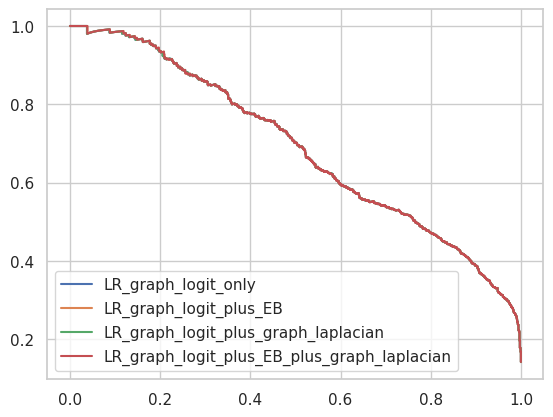

In [128]:
configs = [
    ("LR_graph_logit_only", False, False),
    ("LR_graph_logit_plus_EB", True, False),
    ("LR_graph_logit_plus_graph_laplacian", False, True),
    ("LR_graph_logit_plus_EB_plus_graph_laplacian", True, True),
]

res = []

for cfg in configs:
    model, history, prob_all, logits_np, u_np = train(
        name=cfg[0],
        use_eb=cfg[1],
        use_u=cfg[2]
    )
    res.append(evaluate_scores(cfg[0], Y, prob_all))
    precision, recall, thresholds =  precision_recall_curve(Y[test_mask], prob_all[test_mask])
    plt.plot(recall, precision, label=cfg[0])
    plt.legend()

pd.DataFrame(res)

We obtained a marginally better result with adding EB estimation and Laplacian smoothing. EB estimates seem to add very minimal improvement, but this is expected as the original LR model already includes graph statistics features, by which out EB emphasis would not explain more by what graph statistics already explained. However, Laplacian smoothing does improve a bit better for this model.